In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

import numpy as np
import matplotlib.pyplot as plt

import missingno as msno
from evidently import Report
from evidently.presets import DataDriftPreset

import mlflow
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import fbeta_score, recall_score, roc_auc_score, confusion_matrix, precision_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import joblib
import os
import seaborn as sns

from pathlib import Path
from sklearn import clone

from imblearn.pipeline import Pipeline

ROOT_DIR = r'C:\Users\jfurs\Pythonn\OpenClassrooms\DS\P7\data'

# Load the dataset
train = pd.read_parquet(f'{ROOT_DIR}\\complete_train.parquet')
test = pd.read_parquet(f'{ROOT_DIR}\\complete_test.parquet')

c:\Users\jfurs\anaconda3\envs\labo_api\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DATA DRIFT ANALYSIS

In [49]:
train_cols = list(train.columns)
train_cols.remove("TARGET")

compare_train = train[train_cols]
compare_test = test[train_cols]

# replace bool columns with int
for col in compare_train.columns:
    if compare_train[col].dtype == bool:
        compare_train[col] = compare_train[col].astype(int)
        compare_test[col] = compare_test[col].astype(int)

types = []
for col in compare_train.columns:
    types.append(compare_train[col].dtype)
    types.append(compare_test[col].dtype)

set(types)

{dtype('int64'), dtype('float64')}

In [50]:
report = Report(
    metrics=[DataDriftPreset()],
    include_tests=True
)
  
my_eval = report.run(
    reference_data=compare_train,
    current_data=compare_test
)
my_eval.save_html("report_drift_train_test_datasets.html")

# UTILS

In [51]:
def select_features_by_correlation(
    df,
    target_col,
    n_features=100,
    collinearity_threshold=0.9
):

    df_numeric = df.select_dtypes(include=[np.number, "bool"]).copy()

    # correlation with target
    corr_matrix = df_numeric.corr()
    target_corr = corr_matrix[target_col].drop(target_col).abs()

    # features sorted by correlation with target
    ranked_features = target_corr.sort_values(ascending=False).index.tolist()

    selected_features = []

    for feature in ranked_features:

        if len(selected_features) >= n_features:
            break

        keep = True

        for selected in selected_features:
            corr = df_numeric[[feature, selected]].corr().iloc[0,1]

            if abs(corr) > collinearity_threshold:
                keep = False
                break

        if keep:
            selected_features.append(feature)

    df_final = df_numeric[selected_features + [target_col]]

    removed_columns = [col for col in ranked_features if col not in selected_features]

    return df_final, selected_features, removed_columns

In [52]:
# ─────────────────────────────────────────────
# 2. Métriques métier
# ─────────────────────────────────────────────

def business_cost(y_true, y_proba, threshold, cost_fn=6, cost_fp=2, reward_tp=5, reward_tn=2):
    """
    Coût métier complet tenant compte des 4 cases de la matrice de confusion.

    Pertes :
      - FN (cost_fn)  : défaillant non détecté → perte du capital prêté
      - FP (cost_fp)  : bon client refusé       → manque à gagner

    Gains (valeurs positives à soustraire du coût) :
      - TP (reward_tp) : défaillant correctement refusé → capital préservé
      - TN (reward_tn) : bon client correctement accepté → intérêts encaissés
    """
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    losses = (fn * cost_fn) + (fp * cost_fp)
    gains  = (tp * reward_tp) + (tn * reward_tn)
    return losses - gains


def find_optimal_threshold(y_true, y_proba, cost_fn=6, cost_fp=2, reward_tp=5, reward_tn=2):
    """
    Cherche le threshold qui minimise le coût métier net (pertes - gains).
    Retourne aussi les coûts bruts et les gains séparément pour analyse.
    """
    thresholds = np.linspace(0.01, 0.99, 200)

    results = [
        business_cost(y_true, y_proba, t, cost_fn, cost_fp, reward_tp, reward_tn)
        for t in thresholds
    ]

    best_idx       = np.argmin(results)
    best_threshold = thresholds[best_idx]

    return best_threshold, results, thresholds

# --------------------------------------------------
# Évaluation des métriques
# --------------------------------------------------
def evaluate_model_from_pred(y_true, y_pred, y_proba, beta=2):
    return {
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f_beta":    fbeta_score(y_true, y_pred, beta=beta, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, y_proba),
    }


In [53]:
def train_and_log_model(
    model_name, model, param_grid,
    X_train, y_train, X_val, y_val,
    beta=2, n_iter=20, cv=5,
    cost_fn=4, cost_fp=1,
    reward_tp=4, reward_tn=1,          # ← ajoutés
    tracking_path=Path(r"./mlruns"),
):
    mlflow.set_tracking_uri(tracking_path.as_uri())
    mlflow.set_experiment(model_name)

    print(f"\n{'='*50}")
    print(f"🔍 {model_name} — démarrage de la recherche")
    print(f"   {n_iter} combinaisons × {cv if isinstance(cv, int) else cv.n_splits} folds")
    print(f"   Ratio coût métier → FN: {cost_fn} | FP: {cost_fp} | TP reward: {reward_tp} | TN reward: {reward_tn} | Beta: {beta}")  # ← mis à jour
    print(f"{'='*50}")

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="roc_auc",
        cv=cv,
        refit=False,
        n_jobs=-1,
        random_state=42,
        return_train_score=True,
    )
    random_search.fit(X_train, y_train)

    best_fbeta = -np.inf
    best_model = None
    best_cm    = None

    for i, params in enumerate(random_search.cv_results_["params"]):

        model_i = clone(model).set_params(**params)
        model_i.fit(X_train, y_train)

        y_proba = model_i.predict_proba(X_val)[:, 1]

        optimal_threshold, costs, _ = find_optimal_threshold(
            y_val, y_proba,
            cost_fn=cost_fn, cost_fp=cost_fp,
            reward_tp=reward_tp, reward_tn=reward_tn,   # ← ajoutés
        )

        y_pred  = (y_proba >= optimal_threshold).astype(int)
        metrics = evaluate_model_from_pred(y_val, y_pred, y_proba, beta=beta)
        cm      = confusion_matrix(y_val, y_pred)

        is_best = metrics["f_beta"] > best_fbeta

        marker = " ⭐ MEILLEUR" if is_best else ""
        print(f"  Trial {i+1:>2}/{n_iter} | "
              f"Threshold: {optimal_threshold:.3f} | "
              f"F{beta}: {metrics['f_beta']:.4f} | "
              f"Recall: {metrics['recall']:.4f} | "
              f"AUC: {metrics['roc_auc']:.4f}{marker}")

        with mlflow.start_run(run_name=f"{model_name}_trial_{i + 1}"):
            mlflow.log_param("optimal_threshold", optimal_threshold)
            mlflow.log_param("cost_fn", cost_fn)
            mlflow.log_param("cost_fp", cost_fp)
            mlflow.log_param("reward_tp", reward_tp)    # ← ajoutés
            mlflow.log_param("reward_tn", reward_tn)    # ← ajoutés
            mlflow.log_metric("business_cost", min(costs))
            mlflow.log_params(params)
            mlflow.log_metrics(metrics)
            mlflow.set_tag("is_best", is_best)
            mlflow.sklearn.log_model(model_i, name="model")

        if is_best:
            best_fbeta = metrics["f_beta"]
            best_model = model_i
            best_cm    = cm

    print(f"\n✅ {model_name} terminé — meilleur F{beta}: {best_fbeta:.4f}")
    print(f"   Modèle sauvegardé dans : {tracking_path / f'{model_name}_best_model.pkl'}\n")

    output_path = tracking_path / f"{model_name}_best_model.pkl"
    joblib.dump(best_model, output_path)

    return best_model, best_cm

# DATA PREPARATION

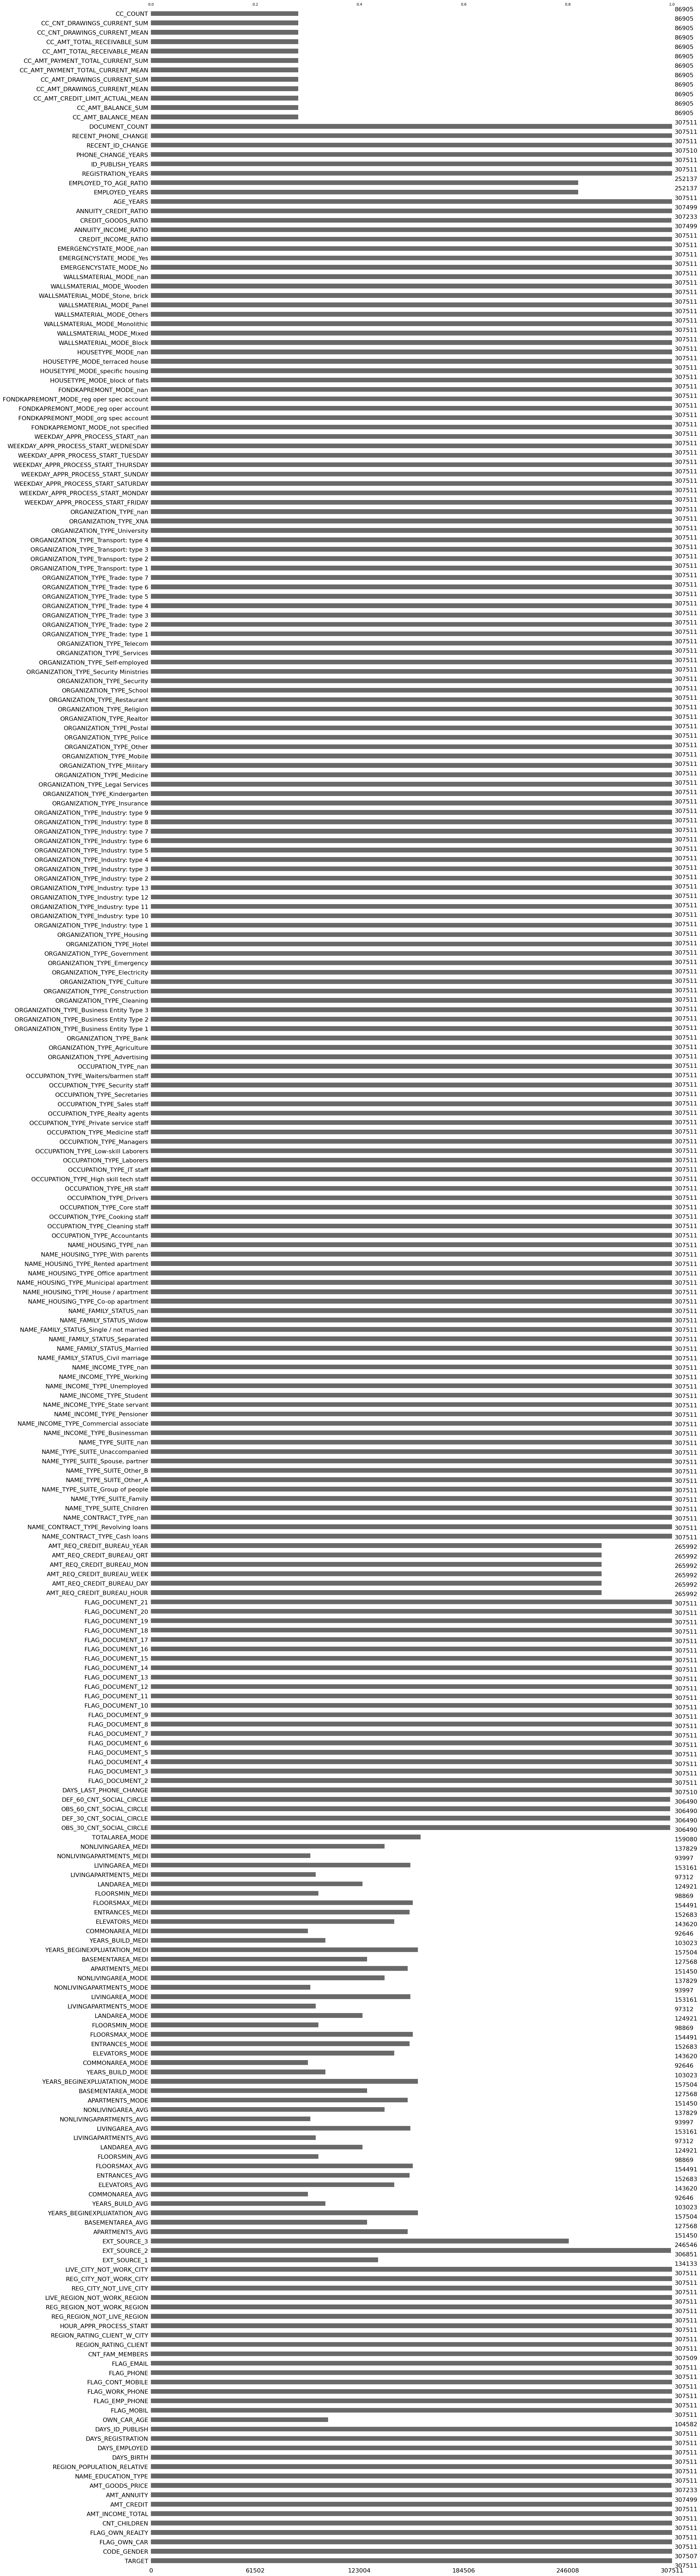

In [54]:
msno.bar(train);

In [55]:
threshold = 0.6  # minimum 60% non-missing

# Proportion de valeurs non-nulles par colonne
non_null_ratio = train.notnull().mean()

# Colonnes à garder
cols_to_keep = non_null_ratio[non_null_ratio >= threshold].index.tolist()

# Colonnes supprimées
cols_removed = non_null_ratio[non_null_ratio < threshold].index.tolist()

# Drop
train = train[cols_to_keep]

train.columns = train.columns.str.replace(r'[^0-9a-zA-Z_]', '_', regex=True)
test.columns = test.columns.str.replace(r'[^0-9a-zA-Z_]', '_', regex=True)

print(f"Colonnes supprimées: {len(cols_removed)}")
train["TARGET"].value_counts()
target_col = "TARGET"  # colonne de classe

# Séparer la classe 0
df_minority = train[train[target_col] == 0]

# Nombre de valeurs manquantes par ligne
missing_count = df_minority.isnull().sum(axis=1)

# Seuil : maximum 1 valeurs manquantes
max_missing = 1

# Garder seulement les lignes avec <= 10 valeurs manquantes
df_minority_clean = df_minority[missing_count <= max_missing]

# Recombiner avec les autres classes
df_majority = train[train[target_col] != 0]
df_clean = pd.concat([df_majority, df_minority_clean])
df_clean["TARGET"].value_counts()

Colonnes supprimées: 57


TARGET
0    199225
1     24825
Name: count, dtype: int64

In [56]:
# splitting features and target
X = df_clean.drop(columns=['TARGET'])
y = df_clean['TARGET']
# stratified split to maintain class distribution in train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [57]:
print(X_train.shape)
print(X_val.shape)

(179240, 214)
(44810, 214)


In [58]:
# pour undersample je dois avoir la target dans X_train mais elle est dans y_train, je vais la remettre dans X_train pour faire l'undersampling
X_train["TARGET"] = y_train

In [59]:
X_train = pd.concat([
    X_train[X_train['TARGET'] != 0],
    X_train[X_train['TARGET'] == 0].dropna()
])

y_train = y_train.loc[X_train.index]

In [60]:
# undersampling sur X_train

X_train_maj = X_train[X_train["TARGET"] == 0]
X_train_min = X_train[X_train["TARGET"] == 1]
X_train_maj_downsampled = X_train_maj.sample(n=2 * len(X_train_min), random_state=42)
X_train_balanced = pd.concat([X_train_maj_downsampled, X_train_min])

y_train = y_train.loc[X_train_balanced.index]

X_train_balanced = X_train_balanced.sample(frac=1, random_state=42)

In [61]:
print(X_train_balanced.shape)
print(y_train.shape)

(59580, 215)
(59580,)


In [62]:
X_train_reduced, cols_kept, cols_removed = select_features_by_correlation(
    X_train_balanced,
    target_col="TARGET",
    n_features=100,
    collinearity_threshold=0.99
)

X_train_reduced.drop(columns=["TARGET"], inplace=True)

print("Kept:", len(cols_kept))
print("Removed:", len(cols_removed))

Kept: 100
Removed: 114


In [63]:
X_train_reduced.shape

(59580, 100)

In [64]:
X_train_reduced.isna().sum().sum()

np.int64(13829)

In [65]:
# updating the other datasets
val_reduced = X_val[cols_kept]
test_reduced = test[cols_kept]

X_train_reduced.sort_index(inplace=True)
y_train.sort_index(inplace=True)

In [66]:
print(X_train_reduced.shape, y_train.shape)

(59580, 100) (59580,)


In [67]:
X_train_reduced.head()

,DAYS_EMPLOYED,EXT_SOURCE_2,EXT_SOURCE_3,FLAG_DOCUMENT_6,NAME_EDUCATION_TYPE,EMPLOYED_TO_AGE_RATIO,PHONE_CHANGE_YEARS,CREDIT_GOODS_RATIO,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,...,WEEKDAY_APPR_PROCESS_START_SATURDAY,ORGANIZATION_TYPE_Restaurant,ORGANIZATION_TYPE_Business_Entity_Type_2,FLAG_DOCUMENT_15,ORGANIZATION_TYPE_Transport__type_2,FONDKAPREMONT_MODE_reg_oper_spec_account,NAME_HOUSING_TYPE_Office_apartment,ORGANIZATION_TYPE_Electricity,WEEKDAY_APPR_PROCESS_START_TUESDAY,FLAG_OWN_REALTY
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,-637,0.262949,0.139376,0,2,0.067329,3.106849,1.158397,2,2,...,False,False,False,0,False,False,False,False,False,1
100014,-679,0.651862,0.363945,0,4,0.066588,2.312329,1.000000,2,2,...,True,False,False,0,False,False,False,False,False,1
100019,-1157,0.346634,0.678568,0,2,0.132562,2.534247,1.211200,3,3,...,True,False,True,0,False,False,False,False,False,1
100026,-4306,0.457143,0.358951,0,2,0.386327,1.282192,1.105600,2,3,...,False,False,False,0,False,False,False,False,False,0
100031,-2628,0.548477,0.190706,0,2,0.140355,0.441096,1.396000,2,3,...,False,False,False,0,False,False,False,False,False,1


In [68]:
X_train_reduced["TARGET"] = y_train

print(X_train_reduced.shape)
print("Quand TARGET == 0: Valeurs manquantes =", X_train_reduced[X_train_reduced["TARGET"] == 0 ].isna().sum().sum())
print("Quand TARGET == 1: Valeurs manquantes =", X_train_reduced[X_train_reduced["TARGET"] == 1 ].isna().sum().sum())

print(y_train.value_counts())

X_train_reduced.drop("TARGET", axis=1, inplace=True)

(59580, 101)
Quand TARGET == 0: Valeurs manquantes = 0
Quand TARGET == 1: Valeurs manquantes = 13829
TARGET
0    39720
1    19860
Name: count, dtype: int64


In [69]:
X_val["TARGET"] = y_val

print(X_val.shape)
print("Quand TARGET == 0: Valeurs manquantes =", X_val[X_val["TARGET"] == 0 ].isna().sum().sum())
print("Quand TARGET == 1: Valeurs manquantes =", X_val[X_val["TARGET"] == 1 ].isna().sum().sum())

print(y_val.value_counts())

X_val.drop("TARGET", axis=1, inplace=True)

(44810, 215)
Quand TARGET == 0: Valeurs manquantes = 2958
Quand TARGET == 1: Valeurs manquantes = 7872
TARGET
0    39845
1     4965
Name: count, dtype: int64


# Imputation + SMOTE dans le pipeline

In [70]:
n1_target = int((y_train == 1).sum() * 1.5)

pipeline = Pipeline(steps=[
    ('imputer', IterativeImputer(random_state=42)),
    ('smote', SMOTE(sampling_strategy={1: n1_target}, random_state=42)),
])

X_train_array, y_train_array = pipeline.fit_resample(X_train_reduced, y_train)

In [71]:
X_train = pd.DataFrame(X_train_array, columns=X_train_reduced.columns)
y_train = pd.Series(y_train_array, name=y_train.name)

print(X_train.shape, y_train.shape)

y_train.value_counts()

(69510, 100) (69510,)


TARGET
0    39720
1    29790
Name: count, dtype: int64

In [72]:
print("X_train shape:", X_train.shape, "   |||   Valeurs manquantes:", X_train.isna().sum().sum())
print("y_train shape:", y_train.shape, "       |||   Valeurs manquantes:", y_train.isna().sum())
print("X_val shape:", X_val.shape, "     |||   Valeurs manquantes:", X_val.isna().sum().sum())
print("y_val shape:", y_val.shape, "         |||   Valeurs manquantes:", y_val.isna().sum())

X_train shape: (69510, 100)    |||   Valeurs manquantes: 0
y_train shape: (69510,)        |||   Valeurs manquantes: 0
X_val shape: (44810, 214)      |||   Valeurs manquantes: 10830
y_val shape: (44810,)          |||   Valeurs manquantes: 0


# ML PART

In [73]:
# modifier les colonnes de X_val pour qu'elles soient dans le même ordre que X_train

In [74]:
X_val = X_val[X_train.columns]

In [75]:
# Hyperparameter grids
lgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, 5, 10]
}

In [76]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

TRACKING_PATH = Path(r"C:\Users\jfurs\Pythonn\OpenClassrooms\DS\P7\mlruns")

BETA   = 2
N_ITER = 20
COST_FN = 10   # coût d'un faux négatif (défaillant non détecté) -> très grave
COST_FP = 2   # coût d'un faux positif (bon client refusé) -> dommage mais limité
COST_TP = 4   # gain d'un vrai positif (défaillant correctement refusé) -> bien 
COST_TN = 1   # gain d'un vrai négatif (bon client correctement accepté) -> bien mais modeste

# LightGBM
lgb_model, lgb_cm = train_and_log_model(
    model_name    = "LightGBM",
    model         = LGBMClassifier(random_state=42),
    param_grid    = lgb_param_grid,
    X_train       = X_train,
    y_train       = y_train,
    X_val         = X_val,
    y_val         = y_val,
    beta          = BETA,
    n_iter        = N_ITER,
    cost_fn       = COST_FN,
    cost_fp       = COST_FP,
    reward_tp     = COST_TP,
    reward_tn     = COST_TN,
    cv            = skf,
    tracking_path = TRACKING_PATH,
)

# XGBoost
xgb_model, xgb_cm = train_and_log_model(
    model_name    = "XGBoost",
    model         = XGBClassifier(eval_metric="logloss", random_state=42),
    param_grid    = xgb_param_grid,
    X_train       = X_train,
    y_train       = y_train,
    X_val         = X_val,
    y_val         = y_val,
    beta          = BETA,
    n_iter        = N_ITER,
    cost_fn       = COST_FN,
    cost_fp       = COST_FP,
    reward_tp     = COST_TP,
    reward_tn     = COST_TN,
    cv            = skf,
    tracking_path = TRACKING_PATH,
)


🔍 LightGBM — démarrage de la recherche
   20 combinaisons × 5 folds
   Ratio coût métier → FN: 10 | FP: 2 | TP reward: 4 | TN reward: 1 | Beta: 2
[LightGBM] [Info] Number of positive: 29790, number of negative: 39720
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20741
[LightGBM] [Info] Number of data points in the train set: 69510, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.428571 -> initscore=-0.287682
[LightGBM] [Info] Start training from score -0.287682
  Trial  1/20 | Threshold: 0.453 | F2: 0.4926 | Recall: 0.5480 | AUC: 0.8079 ⭐ MEILLEUR


c:\Users\jfurs\anaconda3\envs\labo_313\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning:

Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.



[LightGBM] [Info] Number of positive: 29790, number of negative: 39720
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20741
[LightGBM] [Info] Number of data points in the train set: 69510, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.428571 -> initscore=-0.287682
[LightGBM] [Info] Start training from score -0.287682
  Trial  2/20 | Threshold: 0.434 | F2: 0.4744 | Recall: 0.5162 | AUC: 0.7977


c:\Users\jfurs\anaconda3\envs\labo_313\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning:

Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.



[LightGBM] [Info] Number of positive: 29790, number of negative: 39720
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021010 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20741
[LightGBM] [Info] Number of data points in the train set: 69510, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.428571 -> initscore=-0.287682
[LightGBM] [Info] Start training from score -0.287682
  Trial  3/20 | Threshold: 0.458 | F2: 0.4901 | Recall: 0.5498 | AUC: 0.8004


...

  Trial 19/20 | Threshold: 0.369 | F2: 0.3811 | Recall: 0.4405 | AUC: 0.7177


c:\Users\jfurs\anaconda3\envs\labo_313\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning:

Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.



  Trial 20/20 | Threshold: 0.365 | F2: 0.4136 | Recall: 0.4848 | AUC: 0.7378


c:\Users\jfurs\anaconda3\envs\labo_313\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning:

Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.




✅ XGBoost terminé — meilleur F2: 0.4221
   Modèle sauvegardé dans : C:\Users\jfurs\Pythonn\OpenClassrooms\DS\P7\mlruns\XGBoost_best_model.pkl



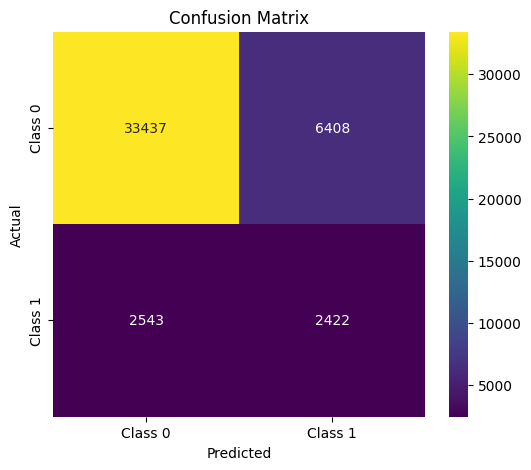

In [83]:
# TN   FP
# FN   TP

labels = ["Class 0", "Class 1"]

plt.figure(figsize=(6,5))
sns.heatmap(xgb_cm, 
            annot=True, 
            fmt='d', 
            cmap='viridis',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

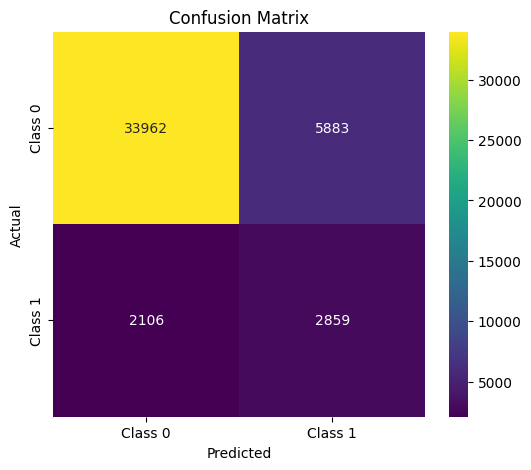

In [84]:
# TN   FP
# FN   TP

labels = ["Class 0", "Class 1"]

plt.figure(figsize=(6,5))
sns.heatmap(lgb_cm, 
            annot=True, 
            fmt='d', 
            cmap='viridis',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [79]:
# TESTS

runs_lgb = mlflow.search_runs(experiment_names=["LightGBM"])
runs_xgb = mlflow.search_runs(experiment_names=["XGBoost"])

# Le meilleur trial de chaque modèle selon F2
best_lgb = runs_lgb.loc[runs_lgb["metrics.f_beta"].idxmax()]
best_xgb = runs_xgb.loc[runs_xgb["metrics.f_beta"].idxmax()]

# Et tu regardes leur coût métier associé
print(best_lgb[["metrics.f_beta", "metrics.business_cost", "params.optimal_threshold"]])
print(best_xgb[["metrics.f_beta", "metrics.business_cost", "params.optimal_threshold"]])

metrics.f_beta                         0.49979
metrics.business_cost                 -12572.0
params.optimal_threshold    0.4335175879396985
Name: 10, dtype: object
metrics.f_beta                        0.422098
metrics.business_cost                  -4879.0
params.optimal_threshold    0.3793467336683417
Name: 13, dtype: object


In [ ]:
# Test sample for test API

In [86]:
train = pd.read_parquet(f'{ROOT_DIR}\\complete_train.parquet')

In [ ]:
train.columns = train.columns.str.replace(r'[^0-9a-zA-Z_]', '_', regex=True)

,DAYS_EMPLOYED,EXT_SOURCE_2,EXT_SOURCE_3,FLAG_DOCUMENT_6,NAME_EDUCATION_TYPE,EMPLOYED_TO_AGE_RATIO,PHONE_CHANGE_YEARS,CREDIT_GOODS_RATIO,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,...,WEEKDAY_APPR_PROCESS_START_SATURDAY,ORGANIZATION_TYPE_Restaurant,ORGANIZATION_TYPE_Business_Entity_Type_2,FLAG_DOCUMENT_15,ORGANIZATION_TYPE_Transport__type_2,FONDKAPREMONT_MODE_reg_oper_spec_account,NAME_HOUSING_TYPE_Office_apartment,ORGANIZATION_TYPE_Electricity,WEEKDAY_APPR_PROCESS_START_TUESDAY,FLAG_OWN_REALTY
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,-637,0.262949,0.139376,0,2,0.067329,3.106849,1.158397,2,2,...,False,False,False,0,False,False,False,False,False,1
100003,-1188,0.622246,NaN,0,4,0.070862,2.268493,1.145199,1,1,...,False,False,False,0,False,False,False,False,False,0
100004,-225,0.555912,0.729567,0,2,0.011814,2.232877,1.000000,2,2,...,False,False,False,0,False,False,False,False,False,1
100006,-3039,0.650442,NaN,0,2,0.159905,1.690411,1.052803,2,2,...,False,False,False,0,False,False,False,False,False,1
100007,-3038,0.322738,NaN,0,2,0.152418,3.030137,1.000000,2,2,...,False,False,False,0,False,False,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456251,-236,0.681632,NaN,0,2,0.025303,0.747945,1.132000,1,1,...,False,False,False,0,False,False,False,False,False,0
456252,365243,0.115992,NaN,0,2,NaN,-0.000000,1.198000,2,2,...,False,False,False,0,False,False,False,False,False,1
456253,-7921,0.535722,0.218859,0,4,0.529266,5.230137,1.158400,3,3,...,False,False,False,0,False,False,False,False,False,1


In [91]:
api_test_sample = train[cols_kept][:20]

api_test_sample.to_csv(f'{ROOT_DIR}\\api_test_sample.csv', index=False)